In [13]:
import os
import re
from collections import defaultdict, Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import polars as pl
import loguru as logger
import matplotlib

from settings.settings_analyze_efizz import Settings_ae
from behave_analysis.process.session import get_experiment
from behave_analysis.utils.rayleigh.load_rayleigh import collect_all_rayleigh_paths, load_all_rayleigh_data
from behave_analysis.utils.rayleigh.manipulate_rayleigh_df import extract_compartment_values, extract_firing_rates
from behave_analysis.utils.creating_directories import make_directory
from settings.settings_analyze_efizz import Settings_ae as Settings
from behave_analysis.analyze.TunED.model import TunEdModel

from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

In [2]:
experiments_objects = [JAL6_flip7_1apr, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

tinny_barrier = [JAL8_tiny_3may, JAL8_21may, JAL7_30apr]

# Mice groups based on session names
mice_groups = {
    "JAL6": ['JAL6_flip7_1apr', 'JAL6_flip3_18mar', 'JAL6_flip4_21mar', 'JAL6_flip5_25mar', 'JAL6_28mar'],
    "JAL3": ['JAL3_25aug', 'JAL3_1sept', 'JAL3_4sept', 'JAL3_7sept'],
    "JAL7": ['JAL7_sesh8_9apr', 'JAL7_sesh9_16apr', 'JAL7_flip5_22mar', 'JAL7_flip2_12mar', 'JAL7_23apr'],
    "JAL8": ['JAL8_flip1_25apr', 'JAL8_flip2_29apr', 'JAL8_flip4_10may', 'JAL8_14may'],
    "JAL4": ['JAL4_3rdSept', 'JAL4_19thSept', 'JAL4_28aug', 'JAL4_11thSept'],
    "JAL5": ['JAL5_8thSept', 'JAL5_21stSept']}


session_NAMES = ["JAL6_flip7_1apr", "JAL6_flip3_18mar", "JAL6_flip4_21mar", "JAL6_flip5_25mar", "JAL6_28mar",
                 "JAL3_25aug", "JAL3_1sept", "JAL3_4sept", "JAL3_7sept", 
                 "JAL005_8thSept", "JAL005_21stSept",
                 "JAL7_sesh8_9apr", "JAL7_sesh9_16apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_23apr",
                 "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip4_10may", "JAL8_14may",
                 "JAL4_3rdSept", "JAL4_19thSept", "JAL4_28aug", "JAL4_11thSept"]

# Store the cell ids in a session -> cluster id -> top two rayleigh values + other thresholds ready for the tuned model

In [3]:
# New code that stores the top two rayleigh angles for each session and cell angle combo and sets a threshold for firing rates

In [4]:
def regex(angle):
    "Remove unwanted characters from angle file string"
    pattern = r'^(.*?)(?=_Rayleigh)'
    match = re.search(pattern, angle)
    assert match, f"Could not find match for {angle}"
    return match.group(0)

def nest_dic():
    """A function to create arbitrarily nested dictionaries"""
    return defaultdict(nest_dic)

In [5]:
# Init Params
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
total_cells = 0
total_sessions = 0
rayleigh_threshold = 0.25
fr_threshold = 2 # Hz
dir = make_directory(r"Z:\Jasmine_Laurence\rayleigh_analysis")
angle_keys = ['hdir_Rayleigh.arrow', 'hsa_Rayleigh.arrow', 'h_postflipbar_a_Rayleigh.arrow', 'h_preflipbar_a_Rayleigh.arrow']
threat_dict_max_rayleigh = nest_dic() # dict[session][cell][condition] = {max_rayleigh_angle}
cell_count = 0
not_meet_threshold = 0

In [6]:
for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)
    paths = collect_all_rayleigh_paths(session = loaded_session, cluster_type = "good", conditions= conditions) # paths[condition][angles]
    condition_data = load_all_rayleigh_data(paths) # condition_data[condition][angles] ~ hdir, hsa, center, post flip, pre flip
    try:
        cluster_msater = pd.read_csv(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "\\" + "spike_count_by_frame_and_goodcluster.csv")
    except:
        print(f"Could not load cluster master for session {session}")
        continue
    
    # extract the spike_clusters column and sort them uniquely from smallest
    spike_clusters = sorted(cluster_msater['spike_clusters'].unique())
    
    # if condition_data keys is empty, skip
    if len(condition_data["shelter_only"].keys()) == 0:
        print(f"Skipping session {session} as no data found")
        continue
    
    nCells = len(condition_data["shelter_only"]["hdir_Rayleigh.arrow"]["Rayleigh"]) # Cells are the same for all conditions and angles in one session
    assert nCells == len(spike_clusters), f"Number of cells {nCells} does not match number of clusters {len(spike_clusters)}"
    cell_count += nCells
    
    for cell in range(nCells):
        tuned_across_conditions = False

        for ci, condition in enumerate(condition_data.keys()):
            
            rayleigh_list = []
            angle_list = []
            tuned = False # A pointer to check if the cell is tuned to any angle in any condition
            rayleigh = 0 # Per condition reset the rayleigh value
            for angle in angle_keys:
                
                sz_fr, tz_fr = extract_firing_rates(condition_data[condition][angle])
                cell_fr = tz_fr[cell] # Focus on threat zone firing rate only
                #Just the threat zone
                output = extract_compartment_values(condition_data[condition][angle], column_name="Rayleigh") # Extract the rayleigh values for THREAT ONLY
                if (
                    (output[cell][1] > rayleigh) # if it's greater than the previous rayleigh value or zero
                    and (output[cell][1] > rayleigh_threshold) # above threshold
                    and (max(cell_fr) > fr_threshold) # above fr threshold
                    ):
                    rayleigh = output[cell][1]
                    max_angle_str = regex(angle)
                    tuned = True
                    tuned_across_conditions = True
                
                if output[cell][1] > rayleigh_threshold:
                    rayleigh_list.append(output[cell][1])
                    angle_list.append(regex(angle))
            
            # Get the indices of the top two largest values in rayleigh_list
            top_indices = np.argsort(rayleigh_list)[-2:]  # Get indices of the two largest values
            top_angles = [angle_list[idx] for idx in top_indices] 
                    
            # For each cell in each session, save the max rayleigh values and corresponding condition | angle combo
            if tuned and len(rayleigh_list) == 2:
                threat_dict_max_rayleigh[session_NAMES[i]][spike_clusters[cell]][condition] = [(top_angles[0], rayleigh_list[top_indices[0]]), (top_angles[1], rayleigh_list[top_indices[1]])]
            else:
                threat_dict_max_rayleigh[session_NAMES[i]][spike_clusters[cell]][condition] = "Not tuned"
            
        if not tuned_across_conditions:
            # Track the number of cells that did not meet the threshold
            not_meet_threshold += 1

Could not load cluster master for session Experiment(nick_name='JAL006', total_sessions=9, mouse_number_pyrat='BAA-1104292', experiment_file_names=None, root_path=WindowsPath('JAL006'), experiment_name='flip', experiment_idx=3, experiment_date='2024_03_18', experiment_time='11_53_29', experiment_path=WindowsPath('JAL006_barrier_flip2_2024_03_18T11_53_29'), shelter_time=[0.25, -1], barrier_time=[68.25, -1], barrier_flip_time=180.25)
Could not load cluster master for session Experiment(nick_name='JAL006', total_sessions=9, mouse_number_pyrat='BAA-1104292', experiment_file_names=None, root_path=WindowsPath('JAL006'), experiment_name='flip', experiment_idx=4, experiment_date='2024_03_21', experiment_time='11_20_34', experiment_path=WindowsPath('JAL006_shelter_barrier_flip_3_2024_03_21T11_20_34'), shelter_time=[0.25, -1], barrier_time=[59.25, -1], barrier_flip_time=172.5)


In [7]:
# Save the threat dict as a pickle file
import pickle
with open(os.path.join(dir, "threat_dict_top2_angles_per_condition_max_ray.pkl"), "wb") as f:
    pickle.dump(threat_dict_max_rayleigh, f)

In [8]:
# open the pickle file
with open(os.path.join(dir, "threat_dict_top2_angles_per_condition_max_ray.pkl"), "rb") as f:
    loaded_threat_dict_max_rayleigh = pickle.load(f)

doing a wilcoxon test
doing a wilcoxon test


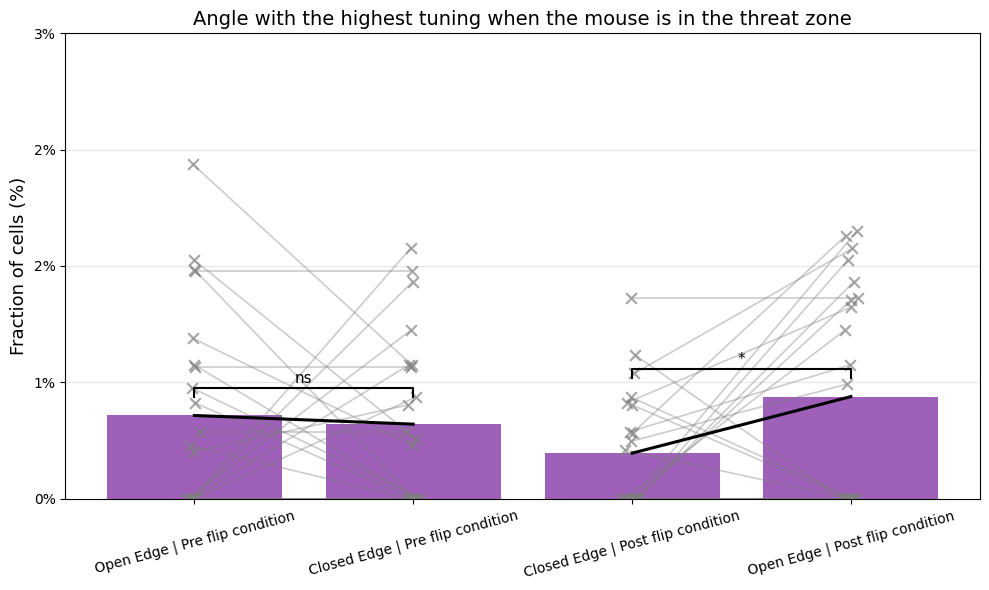

p (Open vs Closed Pre) : 0.7535516091563128
p (Closed vs Open Post): 0.03546470751403722


In [17]:
# Combined: build per-session summary + dynamic % plot (pair significance bars only)
%matplotlib inline
from matplotlib.ticker import FuncFormatter

# --- 1) Build per-session summary -------------------------------------------
target_conditions = ["barrier_pre_flip", "barrier_post_flip"]
angle_labels_of_interest = ["h_preflipbar_a", "h_postflipbar_a"]

# counts_by_session[session][condition] -> dict of totals and angle counts
counts_by_session = {}

for session, cell_dict in loaded_threat_dict_max_rayleigh.items():
    if session not in counts_by_session:
        counts_by_session[session] = {
            c: {"total_cells": 0,
                "tuned_cells": 0,
                "h_preflipbar_a": 0,
                "h_postflipbar_a": 0}
            for c in target_conditions
        }
    for cluster_id, cond_dict in cell_dict.items():
        for cond in target_conditions:
            if cond not in cond_dict:
                continue
            counts_by_session[session][cond]["total_cells"] += 1
            entry = cond_dict[cond]

            if entry == "Not tuned" or entry is None:
                continue
            if not isinstance(entry, (list, tuple)) or len(entry) == 0:
                continue

            try:
                max_angle, _ = max(entry, key=lambda x: x[1])
            except Exception:
                continue

            counts_by_session[session][cond]["tuned_cells"] += 1
            if max_angle in angle_labels_of_interest:
                counts_by_session[session][cond][max_angle] += 1

# Build per-session rows
session_rows = []
for session, conds in counts_by_session.items():
    for cond, c in conds.items():
        tot = c["total_cells"] if c["total_cells"] else 0
        pre_n  = c["h_preflipbar_a"]
        post_n = c["h_postflipbar_a"]
        session_rows.append({
            "session": session,
            "condition": cond,
            "total_cells": tot,
            "h_preflipbar_a_count": pre_n,
            "h_postflipbar_a_count": post_n,
            "pct_pre_over_total":  (pre_n  / tot) if tot else 0.0,
            "pct_post_over_total": (post_n / tot) if tot else 0.0
        })

session_summary_df = pd.DataFrame(session_rows)

# --- 2) Compute group means for the four bars (unweighted mean across sessions)
def mean_or_zero(s):
    return float(s.mean()) if len(s) else 0.0

# slot mapping:
# 0 Open Edge | Pre flip        -> barrier_pre_flip,  pct_pre_over_total
# 1 Closed Edge | Pre flip      -> barrier_pre_flip,  pct_post_over_total
# 2 Closed Edge | Post flip     -> barrier_post_flip, pct_pre_over_total
# 3 Open Edge | Post flip       -> barrier_post_flip, pct_post_over_total
bar_means = [
    mean_or_zero(session_summary_df.query("condition=='barrier_pre_flip'")["pct_pre_over_total"]),
    mean_or_zero(session_summary_df.query("condition=='barrier_pre_flip'")["pct_post_over_total"]),
    mean_or_zero(session_summary_df.query("condition=='barrier_post_flip'")["pct_pre_over_total"]),
    mean_or_zero(session_summary_df.query("condition=='barrier_post_flip'")["pct_post_over_total"]),
]

# --- 3) Dynamic percent plot with per-session scatter & pair-only significance bars ----
x_labels = [
    'Open Edge | Pre flip condition',
    'Closed Edge | Pre flip condition',
    'Closed Edge | Post flip condition',
    'Open Edge | Post flip condition'
]
x = np.arange(4)

# Collect per-session values (fractions) for later significance (simple Wilcoxon if SciPy)
open_pre_vals   = []
closed_pre_vals = []
closed_post_vals= []
open_post_vals  = []

rng = np.random.default_rng(7)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, bar_means, color='#8e44ad', alpha=0.85)

all_session_vals = []
for session in session_summary_df["session"].unique():
    sub = session_summary_df[session_summary_df["session"] == session]
    def pull(cond, col):
        v = sub.loc[sub["condition"]==cond, col]
        return float(v.iloc[0]) if len(v) else np.nan
    y0 = pull("barrier_pre_flip",  "pct_pre_over_total")   # open pre
    y1 = pull("barrier_pre_flip",  "pct_post_over_total")  # closed pre
    y2 = pull("barrier_post_flip", "pct_pre_over_total")   # closed post
    y3 = pull("barrier_post_flip", "pct_post_over_total")  # open post

    xs = x + rng.normal(0, 0.02, size=4)
    ys = np.array([y0, y1, y2, y3], dtype=float)
    all_session_vals.extend(ys[np.isfinite(ys)].tolist())

    ax.scatter(xs, ys, marker='x', s=60, linewidths=1.5, color='gray', alpha=0.7)
    if np.isfinite(y0) and np.isfinite(y1):
        ax.plot([xs[0], xs[1]], [y0, y1], color='gray', alpha=0.4, linewidth=1.2)
        open_pre_vals.append(y0); closed_pre_vals.append(y1)
    if np.isfinite(y2) and np.isfinite(y3):
        ax.plot([xs[2], xs[3]], [y2, y3], color='gray', alpha=0.4, linewidth=1.2)
        closed_post_vals.append(y2); open_post_vals.append(y3)

# Bold mean pair connectors
ax.plot([x[0], x[1]], [bar_means[0], bar_means[1]], color='black', linewidth=2.2)
ax.plot([x[2], x[3]], [bar_means[2], bar_means[3]], color='black', linewidth=2.2)

# Dynamic y limit (fractions)
vals_for_limit = np.array(bar_means + all_session_vals, dtype=float)
vals_for_limit = vals_for_limit[np.isfinite(vals_for_limit)]
ymax = float(vals_for_limit.max()) if vals_for_limit.size else 0.05
y_top = max(0.03, ymax * 1.35)
if y_top > 0.25:
    y_top = min(y_top, 0.25)

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.set_ylim(0, y_top)
ticks = np.linspace(0, y_top, 6 if y_top >= 0.05 else 5)
ax.set_yticks(ticks)

ax.set_ylabel('Fraction of cells (%)', fontsize=13)
ax.set_title('Angle with the highest tuning when the mouse is in the threat zone', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=15)
ax.grid(axis='y', alpha=0.3)

# --- 4) Significance (pair-only) ------------------------------------------------
from scipy.stats import wilcoxon
def p_val(a,b):
    a=np.asarray(a); b=np.asarray(b)
    if len(a)<3 or len(a)!=len(b): return np.nan
    if np.allclose(a,b): return 1.0
    print("doing a wilcoxon test")
    return wilcoxon(a,b,zero_method='wilcox',alternative='two-sided',mode='auto')[1]

p_pre  = p_val(open_pre_vals, closed_pre_vals)
p_post = p_val(open_post_vals, closed_post_vals)

def stars(p):
    if np.isnan(p): return "n/a"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, top_y, p_val, frac_pad):
    lab = stars(p_val)
    y = top_y + frac_pad
    ax.plot([x1, x1, x2, x2], [y, y+frac_pad*0.5, y+frac_pad*0.5, y], lw=1.5, color='k')
    ax.text((x1 + x2)/2, y + frac_pad*0.6, lab, ha='center', va='bottom', fontsize=11)

pad = 0.04 * y_top
add_sig_bar(ax, 0, 1, max(bar_means[0], bar_means[1]), p_pre,  pad)
add_sig_bar(ax, 2, 3, max(bar_means[2], bar_means[3]), p_post, pad)

plt.tight_layout()
plt.show()

print("p (Open vs Closed Pre) :", p_pre)
print("p (Closed vs Open Post):", p_post)

# Only accept cells that are tuned wehn fr is also max with max rayleigh

In [18]:

threat_dict_max_fr = nest_dic() # dict[session][cell][condition] = {max_rayleigh_angle}
cell_count = 0
not_meet_threshold = 0

for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)
    paths = collect_all_rayleigh_paths(session=loaded_session, cluster_type="good", conditions=conditions)
    condition_data = load_all_rayleigh_data(paths)  # condition_data[condition][angle_key]

    try:
        cluster_master = pd.read_csv(
            os.path.join(loaded_session.base_path, loaded_session.processed_path, "spike_count_by_frame_and_goodcluster.csv")
        )
    except Exception as e:
        print(f"Could not load cluster master for session {session}: {e}")
        continue

    spike_clusters = sorted(cluster_master['spike_clusters'].unique())

    # If no data for this session, skip
    if len(condition_data["shelter_only"].keys()) == 0:
        print(f"Skipping session {session} as no data found")
        continue

    # Cells are consistent across angles/conditions within a session
    nCells = len(condition_data["shelter_only"]["hdir_Rayleigh.arrow"]["Rayleigh"])
    assert nCells == len(spike_clusters), f"Number of cells {nCells} != number of clusters {len(spike_clusters)}"
    cell_count += nCells

    for cell in range(nCells):
        tuned_across_conditions = False

        for condition in condition_data.keys():
            # Collect per-angle metrics for this cell & condition
            angle_names = []
            rayleigh_vals = []
            fr_vals = []

            for angle_key in angle_keys:
                # Firing rates for this angle/condition
                sz_fr, tz_fr = extract_firing_rates(condition_data[condition][angle_key])
                cell_fr = tz_fr[cell]  # FR in threat zone for this cell (array or scalar)
                # Reduce FR to a scalar metric (peak); works if array or scalar
                try:
                    fr_val = float(np.max(cell_fr))
                except Exception:
                    fr_val = float(cell_fr)

                # Rayleigh (threat-only; index 1 per your convention)
                rayleigh_arr = extract_compartment_values(
                    condition_data[condition][angle_key], column_name="Rayleigh"
                )
                rl = float(rayleigh_arr[cell][1])

                angle_names.append(regex(angle_key))
                rayleigh_vals.append(rl)
                fr_vals.append(fr_val)

            angle_names = np.array(angle_names, dtype=object)
            rayleigh_vals = np.array(rayleigh_vals, dtype=float)
            fr_vals = np.array(fr_vals, dtype=float)

            # Find angle(s) with the highest firing rate for this condition & cell
            if np.all(~np.isfinite(fr_vals)):
                # No valid FRs; mark not tuned
                threat_dict_max_fr[session_NAMES[i]][spike_clusters[cell]][condition] = "Not tuned"
                continue

            fr_max = np.nanmax(fr_vals)
            fr_winner_mask = np.isclose(fr_vals, fr_max, rtol=0, atol=1e-9)

            # Apply thresholds + require angle to be an FR winner
            keep_mask = (
                (rayleigh_vals > rayleigh_threshold) &
                (fr_vals > fr_threshold) &
                fr_winner_mask
            )

            if not np.any(keep_mask):
                # No angles pass both Rayleigh/FR thresholds AND are FR winners
                threat_dict_max_fr[session_NAMES[i]][spike_clusters[cell]][condition] = "Not tuned"
                continue

            # Among those that pass, take up to the top-2 by Rayleigh (ties handled naturally)
            passing_indices = np.where(keep_mask)[0]
            order = np.argsort(rayleigh_vals[passing_indices])[::-1]  # descending Rayleigh
            top_indices = passing_indices[order[:2]]

            # Save (angle, rayleigh) pairs
            top_list = [(angle_names[idx], float(rayleigh_vals[idx])) for idx in top_indices]
            threat_dict_max_fr[session_NAMES[i]][spike_clusters[cell]][condition] = top_list
            tuned_across_conditions = True

        if not tuned_across_conditions:
            not_meet_threshold += 1


Could not load cluster master for session Experiment(nick_name='JAL006', total_sessions=9, mouse_number_pyrat='BAA-1104292', experiment_file_names=None, root_path=WindowsPath('JAL006'), experiment_name='flip', experiment_idx=3, experiment_date='2024_03_18', experiment_time='11_53_29', experiment_path=WindowsPath('JAL006_barrier_flip2_2024_03_18T11_53_29'), shelter_time=[0.25, -1], barrier_time=[68.25, -1], barrier_flip_time=180.25): [Errno 13] Permission denied: 'Z:\\Jasmine_Laurence\\Experimental_Data\\JAL006\\JAL006_barrier_flip2_2024_03_18T11_53_29\\processed_data\\spike_count_by_frame_and_goodcluster.csv'
Could not load cluster master for session Experiment(nick_name='JAL006', total_sessions=9, mouse_number_pyrat='BAA-1104292', experiment_file_names=None, root_path=WindowsPath('JAL006'), experiment_name='flip', experiment_idx=4, experiment_date='2024_03_21', experiment_time='11_20_34', experiment_path=WindowsPath('JAL006_shelter_barrier_flip_3_2024_03_21T11_20_34'), shelter_time=[0

In [20]:
# save the threat dict fr as a pickle file
with open(os.path.join(dir, "threat_dict_top2_angles_per_condition_max_fr.pkl"), "wb") as f:
    pickle.dump(threat_dict_max_fr, f)

In [21]:
# load the pickle file
with open(os.path.join(dir, "threat_dict_top2_angles_per_condition_max_fr.pkl"), "rb") as f:
    loaded_threat_dict_max_fr = pickle.load(f)

doing a wilcoxon test
doing a wilcoxon test


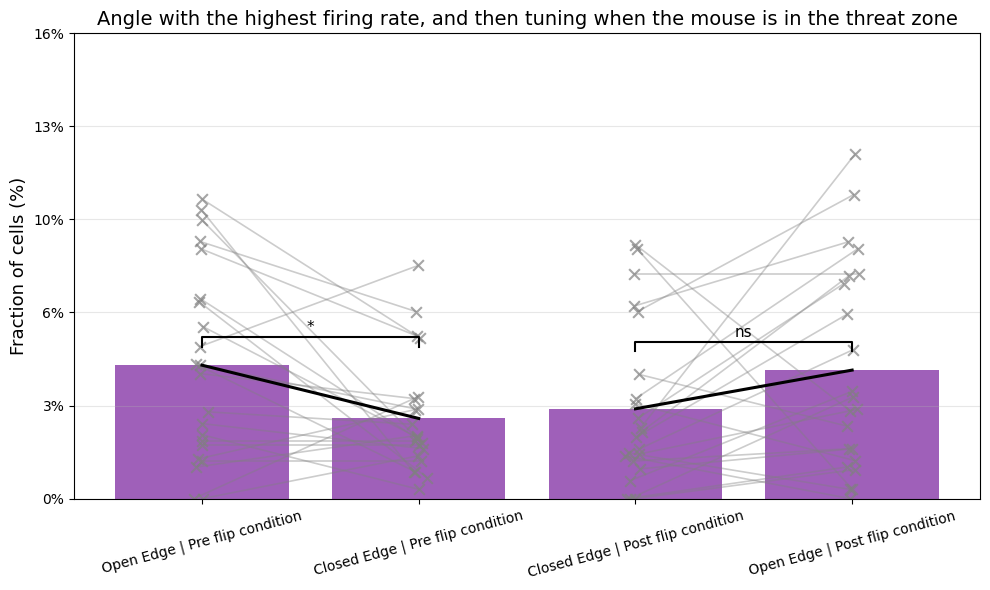

p (Open vs Closed Pre) : 0.021801738635254905
p (Closed vs Open Post): 0.091844728177532


In [23]:
# Combined: build per-session summary + dynamic % plot (pair significance bars only)
%matplotlib inline
from matplotlib.ticker import FuncFormatter

# --- 1) Build per-session summary -------------------------------------------
target_conditions = ["barrier_pre_flip", "barrier_post_flip"]
angle_labels_of_interest = ["h_preflipbar_a", "h_postflipbar_a"]

# counts_by_session[session][condition] -> dict of totals and angle counts
counts_by_session = {}

for session, cell_dict in loaded_threat_dict_max_fr.items():
    if session not in counts_by_session:
        counts_by_session[session] = {
            c: {"total_cells": 0,
                "tuned_cells": 0,
                "h_preflipbar_a": 0,
                "h_postflipbar_a": 0}
            for c in target_conditions
        }
    for cluster_id, cond_dict in cell_dict.items():
        for cond in target_conditions:
            if cond not in cond_dict:
                continue
            counts_by_session[session][cond]["total_cells"] += 1
            entry = cond_dict[cond]

            if entry == "Not tuned" or entry is None:
                continue
            if not isinstance(entry, (list, tuple)) or len(entry) == 0:
                continue

            try:
                max_angle, _ = max(entry, key=lambda x: x[1])
            except Exception:
                continue

            counts_by_session[session][cond]["tuned_cells"] += 1
            if max_angle in angle_labels_of_interest:
                counts_by_session[session][cond][max_angle] += 1

# Build per-session rows
session_rows = []
for session, conds in counts_by_session.items():
    for cond, c in conds.items():
        tot = c["total_cells"] if c["total_cells"] else 0
        pre_n  = c["h_preflipbar_a"]
        post_n = c["h_postflipbar_a"]
        session_rows.append({
            "session": session,
            "condition": cond,
            "total_cells": tot,
            "h_preflipbar_a_count": pre_n,
            "h_postflipbar_a_count": post_n,
            "pct_pre_over_total":  (pre_n  / tot) if tot else 0.0,
            "pct_post_over_total": (post_n / tot) if tot else 0.0
        })

session_summary_df = pd.DataFrame(session_rows)

# --- 2) Compute group means for the four bars (unweighted mean across sessions)
def mean_or_zero(s):
    return float(s.mean()) if len(s) else 0.0

# slot mapping:
# 0 Open Edge | Pre flip        -> barrier_pre_flip,  pct_pre_over_total
# 1 Closed Edge | Pre flip      -> barrier_pre_flip,  pct_post_over_total
# 2 Closed Edge | Post flip     -> barrier_post_flip, pct_pre_over_total
# 3 Open Edge | Post flip       -> barrier_post_flip, pct_post_over_total
bar_means = [
    mean_or_zero(session_summary_df.query("condition=='barrier_pre_flip'")["pct_pre_over_total"]),
    mean_or_zero(session_summary_df.query("condition=='barrier_pre_flip'")["pct_post_over_total"]),
    mean_or_zero(session_summary_df.query("condition=='barrier_post_flip'")["pct_pre_over_total"]),
    mean_or_zero(session_summary_df.query("condition=='barrier_post_flip'")["pct_post_over_total"]),
]

# --- 3) Dynamic percent plot with per-session scatter & pair-only significance bars ----
x_labels = [
    'Open Edge | Pre flip condition',
    'Closed Edge | Pre flip condition',
    'Closed Edge | Post flip condition',
    'Open Edge | Post flip condition'
]
x = np.arange(4)

# Collect per-session values (fractions) for later significance (simple Wilcoxon if SciPy)
open_pre_vals   = []
closed_pre_vals = []
closed_post_vals= []
open_post_vals  = []

rng = np.random.default_rng(7)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, bar_means, color='#8e44ad', alpha=0.85)

all_session_vals = []
for session in session_summary_df["session"].unique():
    sub = session_summary_df[session_summary_df["session"] == session]
    def pull(cond, col):
        v = sub.loc[sub["condition"]==cond, col]
        return float(v.iloc[0]) if len(v) else np.nan
    y0 = pull("barrier_pre_flip",  "pct_pre_over_total")   # open pre
    y1 = pull("barrier_pre_flip",  "pct_post_over_total")  # closed pre
    y2 = pull("barrier_post_flip", "pct_pre_over_total")   # closed post
    y3 = pull("barrier_post_flip", "pct_post_over_total")  # open post

    xs = x + rng.normal(0, 0.02, size=4)
    ys = np.array([y0, y1, y2, y3], dtype=float)
    all_session_vals.extend(ys[np.isfinite(ys)].tolist())

    ax.scatter(xs, ys, marker='x', s=60, linewidths=1.5, color='gray', alpha=0.7)
    if np.isfinite(y0) and np.isfinite(y1):
        ax.plot([xs[0], xs[1]], [y0, y1], color='gray', alpha=0.4, linewidth=1.2)
        open_pre_vals.append(y0); closed_pre_vals.append(y1)
    if np.isfinite(y2) and np.isfinite(y3):
        ax.plot([xs[2], xs[3]], [y2, y3], color='gray', alpha=0.4, linewidth=1.2)
        closed_post_vals.append(y2); open_post_vals.append(y3)

# Bold mean pair connectors
ax.plot([x[0], x[1]], [bar_means[0], bar_means[1]], color='black', linewidth=2.2)
ax.plot([x[2], x[3]], [bar_means[2], bar_means[3]], color='black', linewidth=2.2)

# Dynamic y limit (fractions)
vals_for_limit = np.array(bar_means + all_session_vals, dtype=float)
vals_for_limit = vals_for_limit[np.isfinite(vals_for_limit)]
ymax = float(vals_for_limit.max()) if vals_for_limit.size else 0.05
y_top = max(0.03, ymax * 1.35)
if y_top > 0.25:
    y_top = min(y_top, 0.25)

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.set_ylim(0, y_top)
ticks = np.linspace(0, y_top, 6 if y_top >= 0.05 else 5)
ax.set_yticks(ticks)

ax.set_ylabel('Fraction of cells (%)', fontsize=13)
ax.set_title('Angle with the highest firing rate, and then tuning when the mouse is in the threat zone', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=15)
ax.grid(axis='y', alpha=0.3)

# --- 4) Significance (pair-only) ------------------------------------------------
from scipy.stats import wilcoxon
def p_val(a,b):
    a=np.asarray(a); b=np.asarray(b)
    if len(a)<3 or len(a)!=len(b): return np.nan
    if np.allclose(a,b): return 1.0
    print("doing a wilcoxon test")
    return wilcoxon(a,b,zero_method='wilcox',alternative='two-sided',mode='auto')[1]

p_pre  = p_val(open_pre_vals, closed_pre_vals)
p_post = p_val(open_post_vals, closed_post_vals)

def stars(p):
    if np.isnan(p): return "n/a"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, top_y, p_val, frac_pad):
    lab = stars(p_val)
    y = top_y + frac_pad
    ax.plot([x1, x1, x2, x2], [y, y+frac_pad*0.5, y+frac_pad*0.5, y], lw=1.5, color='k')
    ax.text((x1 + x2)/2, y + frac_pad*0.6, lab, ha='center', va='bottom', fontsize=11)

pad = 0.04 * y_top
add_sig_bar(ax, 0, 1, max(bar_means[0], bar_means[1]), p_pre,  pad)
add_sig_bar(ax, 2, 3, max(bar_means[2], bar_means[3]), p_post, pad)

plt.tight_layout()
plt.show()

print("p (Open vs Closed Pre) :", p_pre)
print("p (Closed vs Open Post):", p_post)